✅ 运行设备: mps
[TRAIN - hazelnut] 加载: 200 张. (异常样本数: 0)
[TEST - hazelnut] 加载: 55 张. (异常样本数: 15)

>>> 开始训练类别: hazelnut
Epoch [10/100] Loss: 0.001163
Epoch [20/100] Loss: 0.000636
Epoch [30/100] Loss: 0.000514
Epoch [40/100] Loss: 0.000439
Epoch [50/100] Loss: 0.000423
Epoch [60/100] Loss: 0.000345
Epoch [70/100] Loss: 0.000340
Epoch [80/100] Loss: 0.000308
Epoch [90/100] Loss: 0.000270
Epoch [100/100] Loss: 0.000267

>>> 开始评估...

★ AUROC (hazelnut): 0.8633


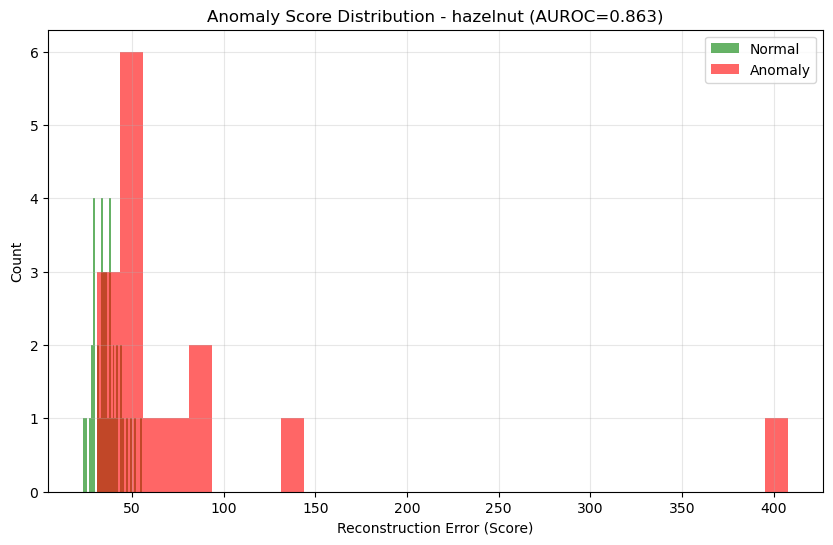

[TRAIN - zipper] 加载: 200 张. (异常样本数: 0)
[TEST - zipper] 加载: 47 张. (异常样本数: 15)

>>> 开始训练类别: zipper
Epoch [10/100] Loss: 0.002536
Epoch [20/100] Loss: 0.001727
Epoch [30/100] Loss: 0.001481
Epoch [40/100] Loss: 0.001396
Epoch [50/100] Loss: 0.001360
Epoch [60/100] Loss: 0.001314
Epoch [70/100] Loss: 0.001300
Epoch [80/100] Loss: 0.001258
Epoch [90/100] Loss: 0.001071
Epoch [100/100] Loss: 0.000925

>>> 开始评估...

★ AUROC (zipper): 0.4479


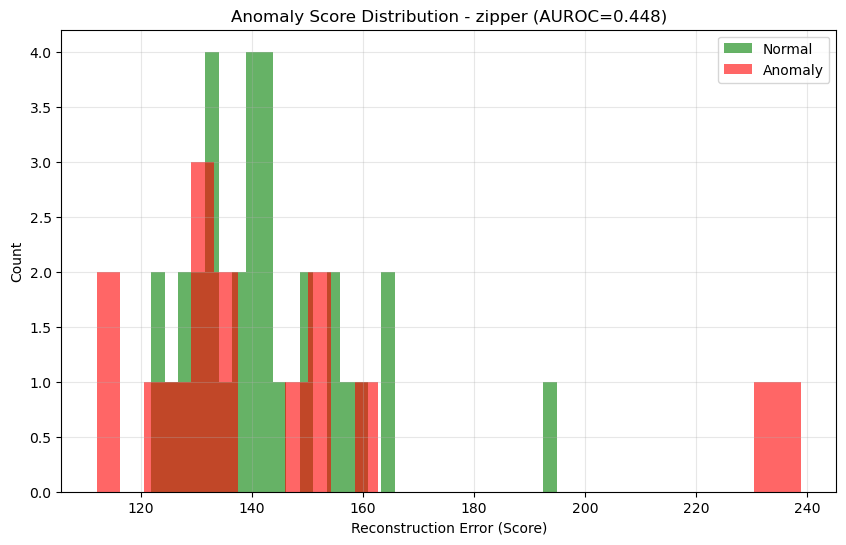

In [2]:
import os
import json
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image
from sklearn.metrics import roc_auc_score

import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import DataLoader, Dataset
from torchvision import transforms

# ==========================================
# 1. 配置与设备选择 (针对 M 芯片优化)
# ==========================================
def get_device():
    if torch.backends.mps.is_available():
        return torch.device("mps")
    elif torch.cuda.is_available():
        return torch.device("cuda")
    else:
        return torch.device("cpu")

DEVICE = get_device()
print(f"✅ 运行设备: {DEVICE}")

# 超参数配置
BATCH_SIZE = 32
LR = 1e-3
EPOCHS = 100  # 增加轮数以确保收敛
IMG_SIZE = 224
CATEGORY = 'hazelnut' # 可选: 'hazelnut' 或 'zipper'

# ==========================================
# 2. 数据集定义 (支持 JSON 标签)
# ==========================================
class AnomalyDataset(Dataset):
    def __init__(self, root_dir, category, mode='train', json_file=None, transform=None):
        self.root_dir = root_dir
        self.category = category
        self.mode = mode
        self.transform = transform
        self.image_paths = []
        self.labels = [] # 0: Normal, 1: Anomaly

        # --- 训练模式 ---
        if self.mode == 'train':
            # 策略：优先寻找 'train/good' 文件夹（纯净正常样本）
            # 如果不存在，则读取 'train' 下所有图片（可能含有污染数据）
            train_good_dir = os.path.join(root_dir, category, 'train', 'good')
            train_dir = os.path.join(root_dir, category, 'train')
            
            search_dir = train_good_dir if os.path.exists(train_good_dir) else train_dir
            
            valid_exts = {'.png', '.jpg', '.jpeg', '.bmp'}
            if os.path.exists(search_dir):
                for root, _, files in os.walk(search_dir):
                    for file in files:
                        if os.path.splitext(file)[1].lower() in valid_exts:
                            self.image_paths.append(os.path.join(root, file))
                            self.labels.append(0) # 训练集默认标记为正常
            else:
                print(f"⚠️ 警告: 未找到训练目录: {search_dir}")

        # --- 测试模式 (依赖 JSON) ---
        elif self.mode == 'test':
            if json_file is None or not os.path.exists(json_file):
                raise ValueError("测试模式需要提供有效的 json_file 路径")
            
            with open(json_file, 'r') as f:
                labels_data = json.load(f)
            
            # 遍历 JSON 中的每个条目
            # JSON 格式示例: "hazelnut/test/001.png": { "label": "good", ... }
            for rel_path, info in labels_data.items():
                # 只加载当前指定类别 (hazelnut 或 zipper) 的数据
                if rel_path.startswith(category):
                    full_path = os.path.join(root_dir, rel_path)
                    
                    if os.path.exists(full_path):
                        self.image_paths.append(full_path)
                        # 解析标签: good -> 0, bad -> 1
                        label_str = info.get('label', 'good')
                        self.labels.append(1 if label_str == 'bad' else 0)
                    else:
                        # 仅在调试时开启，防止刷屏
                        # print(f"缺失文件: {full_path}")
                        pass

        print(f"[{mode.upper()} - {category}] 加载: {len(self.image_paths)} 张. (异常样本数: {sum(self.labels)})")

    def __len__(self):
        return len(self.image_paths)

    def __getitem__(self, idx):
        img_path = self.image_paths[idx]
        label = self.labels[idx]
        
        try:
            image = Image.open(img_path).convert('RGB')
            if self.transform:
                image = self.transform(image)
        except Exception as e:
            print(f"Error loading {img_path}: {e}")
            image = torch.zeros((3, IMG_SIZE, IMG_SIZE))
            
        return image, label

# ==========================================
# 3. 模型定义：卷积自编码器 (CAE)
# ==========================================
class ConvAutoencoder(nn.Module):
    def __init__(self):
        super(ConvAutoencoder, self).__init__()
        
        # Encoder: [B, 3, 224, 224] -> [B, 256, 14, 14]
        self.encoder = nn.Sequential(
            nn.Conv2d(3, 32, 4, stride=2, padding=1),  # [112, 112]
            nn.BatchNorm2d(32),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(32, 64, 4, stride=2, padding=1), # [56, 56]
            nn.BatchNorm2d(64),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(64, 128, 4, stride=2, padding=1), # [28, 28]
            nn.BatchNorm2d(128),
            nn.LeakyReLU(0.2, inplace=True),
            
            nn.Conv2d(128, 256, 4, stride=2, padding=1), # [14, 14]
            nn.BatchNorm2d(256),
            nn.LeakyReLU(0.2, inplace=True),
        )
        
        # Decoder: [B, 256, 14, 14] -> [B, 3, 224, 224]
        self.decoder = nn.Sequential(
            nn.ConvTranspose2d(256, 128, 4, stride=2, padding=1),
            nn.BatchNorm2d(128),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(128, 64, 4, stride=2, padding=1),
            nn.BatchNorm2d(64),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(64, 32, 4, stride=2, padding=1),
            nn.BatchNorm2d(32),
            nn.ReLU(inplace=True),
            
            nn.ConvTranspose2d(32, 3, 4, stride=2, padding=1),
            nn.Sigmoid() # 输出归一化到 [0, 1]
        )

    def forward(self, x):
        z = self.encoder(x)
        x_recon = self.decoder(z)
        return x_recon

# ==========================================
# 4. 训练与评估逻辑
# ==========================================
def train_model(model, dataloader, optimizer, criterion, epochs):
    model.train()
    print(f"\n>>> 开始训练类别: {CATEGORY}")
    
    for epoch in range(epochs):
        total_loss = 0
        for imgs, _ in dataloader:
            imgs = imgs.to(DEVICE)
            
            # 重构任务
            recon = model(imgs)
            loss = criterion(recon, imgs)
            
            optimizer.zero_grad()
            loss.backward()
            optimizer.step()
            
            total_loss += loss.item()
            
        if (epoch+1) % 10 == 0:
            avg_loss = total_loss / len(dataloader)
            print(f"Epoch [{epoch+1}/{epochs}] Loss: {avg_loss:.6f}")

def evaluate_model(model, dataloader):
    model.eval()
    criterion = nn.MSELoss(reduction='none') 
    
    anomaly_scores = []
    true_labels = []
    
    print("\n>>> 开始评估...")
    with torch.no_grad():
        for imgs, labels in dataloader:
            imgs = imgs.to(DEVICE)
            recon = model(imgs)
            
            # 计算每张图的 MSE 损失 (Pixel-wise error)
            # loss shape: [Batch, Channel, Height, Width]
            loss = criterion(recon, imgs)
            
            # 策略：对所有像素误差求和，作为该图片的“异常分数”
            score = torch.sum(loss, dim=(1, 2, 3))
            
            anomaly_scores.extend(score.cpu().numpy())
            true_labels.extend(labels.numpy())
            
    return np.array(true_labels), np.array(anomaly_scores)

# ==========================================
# 5. 可视化与主程序
# ==========================================
if __name__ == "__main__":
    # --- 路径配置 ---
    # 请确保此路径指向包含 'hazelnut' 和 'zipper' 的父文件夹
    # 且该目录下有 'image_anomaly_labels.json'
    DATA_ROOT = "./Image_Anomaly_Detection" 
    JSON_PATH = os.path.join(DATA_ROOT, "image_anomaly_labels.json")

    # 数据预处理
    data_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
    
    # 检查文件是否存在
    if not os.path.exists(DATA_ROOT) or not os.path.exists(JSON_PATH):
        print(f"❌ 错误: 找不到数据集路径或JSON文件。\n期待路径: {DATA_ROOT}\n期待JSON: {JSON_PATH}")
    else:
        # 1. 准备数据集
        # 训练集：自动寻找 train/good
        train_ds = AnomalyDataset(DATA_ROOT, CATEGORY, mode='train', transform=data_transforms)
        # 测试集：使用 JSON 标签
        test_ds = AnomalyDataset(DATA_ROOT, CATEGORY, mode='test', json_file=JSON_PATH, transform=data_transforms)
        
        if len(train_ds) == 0:
            print("❌ 训练集为空，请检查文件夹结构。期待结构: Image_Anomaly_Detection/hazelnut/train/good/*.png")
        else:
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
            
            # 2. 初始化模型
            model = ConvAutoencoder().to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LR)
            criterion = nn.MSELoss()
            
            # 3. 训练
            train_model(model, train_loader, optimizer, criterion, EPOCHS)
            
            # 4. 评估
            if len(test_ds) > 0:
                y_true, y_scores = evaluate_model(model, test_loader)
                
                # 计算 AUROC
                try:
                    auroc = roc_auc_score(y_true, y_scores)
                    print(f"\n★ AUROC ({CATEGORY}): {auroc:.4f}")
                except ValueError:
                    print("\n⚠️ 无法计算 AUROC (可能测试集中只有一种类别)")
                
                # 绘制分布图 (统计学可视化)
                plt.figure(figsize=(10, 6))
                plt.hist(y_scores[y_true==0], bins=30, alpha=0.6, color='green', label='Normal')
                plt.hist(y_scores[y_true==1], bins=30, alpha=0.6, color='red', label='Anomaly')
                plt.title(f'Anomaly Score Distribution - {CATEGORY} (AUROC={auroc:.3f})')
                plt.xlabel('Reconstruction Error (Score)')
                plt.ylabel('Count')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.savefig('hazelnut.png')
                plt.show() # 在 Jupyter 或 IDE 中显示
                
            else:
                print("测试集为空，跳过评估。")
CATEGORY = 'zipper'
if __name__ == "__main__":
    # --- 路径配置 ---
    # 请确保此路径指向包含 'hazelnut' 和 'zipper' 的父文件夹
    # 且该目录下有 'image_anomaly_labels.json'
    DATA_ROOT = "./Image_Anomaly_Detection" 
    JSON_PATH = os.path.join(DATA_ROOT, "image_anomaly_labels.json")

    # 数据预处理
    data_transforms = transforms.Compose([
        transforms.Resize((IMG_SIZE, IMG_SIZE)),
        transforms.ToTensor(),
    ])
    
    # 检查文件是否存在
    if not os.path.exists(DATA_ROOT) or not os.path.exists(JSON_PATH):
        print(f"❌ 错误: 找不到数据集路径或JSON文件。\n期待路径: {DATA_ROOT}\n期待JSON: {JSON_PATH}")
    else:
        # 1. 准备数据集
        # 训练集：自动寻找 train/good
        train_ds = AnomalyDataset(DATA_ROOT, CATEGORY, mode='train', transform=data_transforms)
        # 测试集：使用 JSON 标签
        test_ds = AnomalyDataset(DATA_ROOT, CATEGORY, mode='test', json_file=JSON_PATH, transform=data_transforms)
        
        if len(train_ds) == 0:
            print("❌ 训练集为空，请检查文件夹结构。期待结构: Image_Anomaly_Detection/hazelnut/train/good/*.png")
        else:
            train_loader = DataLoader(train_ds, batch_size=BATCH_SIZE, shuffle=True)
            test_loader = DataLoader(test_ds, batch_size=BATCH_SIZE, shuffle=False)
            
            # 2. 初始化模型
            model = ConvAutoencoder().to(DEVICE)
            optimizer = optim.Adam(model.parameters(), lr=LR)
            criterion = nn.MSELoss()
            
            # 3. 训练
            train_model(model, train_loader, optimizer, criterion, EPOCHS)
            
            # 4. 评估
            if len(test_ds) > 0:
                y_true, y_scores = evaluate_model(model, test_loader)
                
                # 计算 AUROC
                try:
                    auroc = roc_auc_score(y_true, y_scores)
                    print(f"\n★ AUROC ({CATEGORY}): {auroc:.4f}")
                except ValueError:
                    print("\n⚠️ 无法计算 AUROC (可能测试集中只有一种类别)")
                
                # 绘制分布图 (统计学可视化)
                plt.figure(figsize=(10, 6))
                plt.hist(y_scores[y_true==0], bins=30, alpha=0.6, color='green', label='Normal')
                plt.hist(y_scores[y_true==1], bins=30, alpha=0.6, color='red', label='Anomaly')
                plt.title(f'Anomaly Score Distribution - {CATEGORY} (AUROC={auroc:.3f})')
                plt.xlabel('Reconstruction Error (Score)')
                plt.ylabel('Count')
                plt.legend()
                plt.grid(True, alpha=0.3)
                plt.savefig('zipper.png')
                plt.show() # 在 Jupyter 或 IDE 中显示
                
            else:
                print("测试集为空，跳过评估。")